<img style="float:left" width="70%" src="pics/escudo_COLOR_1L_DCHA.png">
<img style="float:right" width="15%" src="pics/PythonLogo.svg">
<br style="clear:both;">

<h2 style="display: inline-block; padding: 4mm; padding-left: 2em; background-color: navy; line-height: 1.3em; color: white; border-radius: 10px;">Contornos activos para segmentación.</h2>

### Contornos activos y *Morphological Snakes*
#### Author: Pedro Latorre Carmona

##### Curso 2025-2026

Versión 1.0

---

Tengo que añadir medidas de evaluacion a cada imagen a la que aplico los metodos. Estas medidas son sensibilidad Especificidad y Precisión Global. Las fórmulas estan en la diapositiva 81 del T4 de teoría.

Hay que ver que el numero corresponde correctamente con la representacion de la imagen y explicarlo

Sensibilidad y esecifidad del 50% es muy mala hay que intentar los mejores que se puedan

Hay que evaluar la calidad que da la segmentacion para cada una de las imágenes para cada uno de los métodos

Para evaluar la calidad hay que segementar una imagen a mano y comparar el resultado que nos da el programa con el nuestro. Es decir necesitaos la máscara

Crear y mostrar la marcara de cada segmentación que hacemos.

Tres imágenes en las que mostrar los resultados ecografía en escala de grises y lagos y estralla en color

Poner imagen comparativa máscaras

Invenstigar valor de alfa y beta etudio de variación

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from imageio import imread
import imageio

# Importaciones de scikit-image (para el Objetivo 1)
from skimage.color import rgb2gray
from skimage import data
from skimage.filters import gaussian
from skimage.segmentation import active_contour

# Importaciones del repositorio morphsnakes (para el Objetivo 1 y 2)
# (Asegúrate de que el archivo morphsnakes.py esté en el mismo directorio)
import morphsnakes as ms

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread
from skimage.color import rgb2gray
from sklearn.metrics import confusion_matrix

def binarizar_mascara(imagen):
    """
    Convierte una máscara (ya sea RGB o escala de grises) a binaria (0 y 1).
    Asume que el objeto es blanco (o claro) y el fondo negro (u oscuro).
    """
    if imagen is None:
        return None
    
    imagen = np.array(imagen)
    
    # 1. Si la imagen tiene 3 canales (es RGB), la pasamos a gris
    if imagen.ndim == 3:
        # Nota: rgb2gray convierte a float entre 0 y 1 automáticamente
        imagen = rgb2gray(imagen)
    
    # 2. Si la imagen ya venía en escala de grises (2 dimensiones)
    # pero es de tipo entero (0-255), la normalizamos a 0-1
    elif imagen.max() > 1:
        imagen = imagen / 255.0
        
    # 3. Umbralización
    # Cualquier cosa que no sea negro absoluto (> 0.1) se convierte en 1 (Objeto)
    return (imagen > 0.1).astype(int)

def calcular_y_mostrar_metricas(nombre_imagen, mask_gt, mask_seg):
    """Calcula Sensibilidad, Especificidad y Precisión."""
    if mask_gt is None or mask_seg is None:
        print(f"Salto métricas para {nombre_imagen}: Falta máscara.")
        return

    # Aplanar arrays
    y_true = mask_gt.flatten()
    y_pred = mask_seg.flatten()

    # Comprobar tamaños
    if y_true.shape != y_pred.shape:
        print(f"Error tamaño en {nombre_imagen}: GT {y_true.shape} vs Seg {y_pred.shape}")
        return

    # Matriz de confusión
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    # Cálculos
    sensibilidad = tp / (tp + fn) if (tp + fn) > 0 else 0
    especificidad = tn / (tn + fp) if (tn + fp) > 0 else 0
    precision = (tp + tn) / (tp + tn + fp + fn)

    print(f"--- {nombre_imagen} ---")
    print(f"Sensibilidad:  {sensibilidad:.2%}")
    print(f"Especificidad: {especificidad:.2%}")
    print(f"Precisión:     {precision:.2%}")
    print("-" * 20)

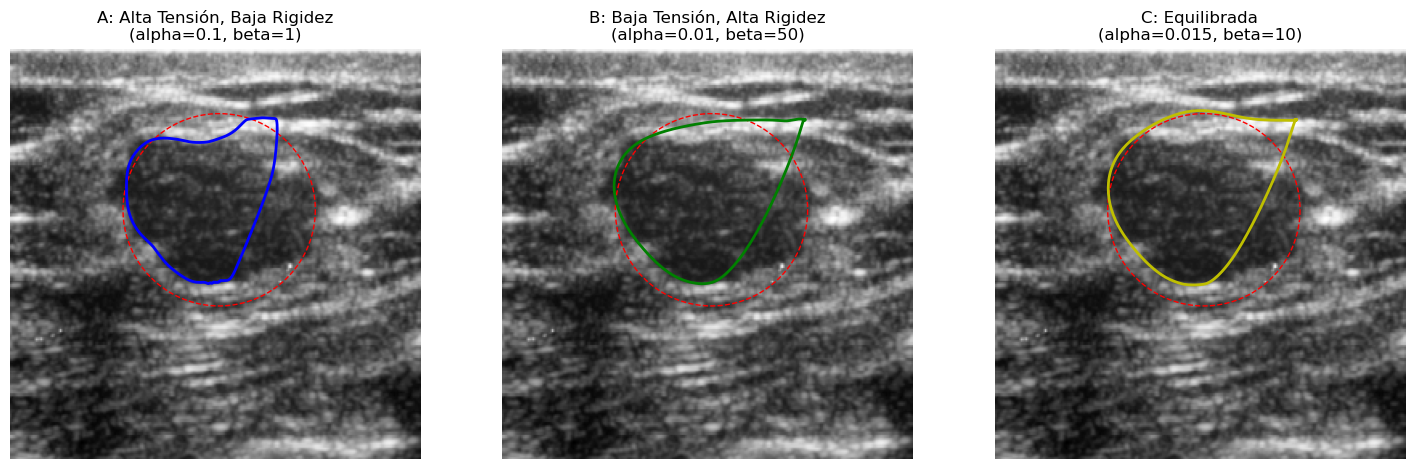

Conclusión del estudio: Un valor alto de Beta (Rigidez) ayuda a mantener la forma suave del nódulo, evitando que el ruido de la ecografía deforme el contorno.


In [21]:
# Cargar imagen de ecografía
img_nodulo = imread('images/mama07ORI.bmp')
# Si tiene 3 canales, convertir a gris, si no, normalizar
if len(img_nodulo.shape) > 2:
    img_nodulo_gray = rgb2gray(img_nodulo)
else:
    img_nodulo_gray = img_nodulo / 255.0

# Inicialización circular para el nódulo (ajustada visualmente)
s = np.linspace(0, 2*np.pi, 400)
r = 100 + 60 * np.sin(s) # Fila centro + radio
c = 130 + 60 * np.cos(s) # Columna centro + radio
init_nodulo = np.array([r, c]).T

# --- ESTUDIO DE VARIACIÓN DE ALFA Y BETA ---
# Alpha: Tensión (contrae la serpiente). Beta: Rigidez (suaviza la serpiente).

# Configuración 1: Alta tensión (contrae rápido), Baja rigidez (se ajusta mucho al ruido)
snake_1 = active_contour(gaussian(img_nodulo_gray, 3),
                       init_nodulo, alpha=0.1, beta=1, w_line=0, w_edge=1, gamma=0.001)

# Configuración 2: Baja tensión, Alta rigidez (forma más redonda/suave)
snake_2 = active_contour(gaussian(img_nodulo_gray, 3),
                       init_nodulo, alpha=0.01, beta=50, w_line=0, w_edge=1, gamma=0.001)

# Configuración 3: Equilibrada
snake_3 = active_contour(gaussian(img_nodulo_gray, 3),
                       init_nodulo, alpha=0.015, beta=10, w_line=0, w_edge=1, gamma=0.001)

# Mostrar Comparativa
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

ax[0].imshow(img_nodulo_gray, cmap='gray')
ax[0].plot(init_nodulo[:, 1], init_nodulo[:, 0], '--r', lw=1, label='Init')
ax[0].plot(snake_1[:, 1], snake_1[:, 0], '-b', lw=2, label='Snake')
ax[0].set_title('A: Alta Tensión, Baja Rigidez\n(alpha=0.1, beta=1)')
ax[0].axis('off')

ax[1].imshow(img_nodulo_gray, cmap='gray')
ax[1].plot(init_nodulo[:, 1], init_nodulo[:, 0], '--r', lw=1)
ax[1].plot(snake_2[:, 1], snake_2[:, 0], '-g', lw=2)
ax[1].set_title('B: Baja Tensión, Alta Rigidez\n(alpha=0.01, beta=50)')
ax[1].axis('off')

ax[2].imshow(img_nodulo_gray, cmap='gray')
ax[2].plot(init_nodulo[:, 1], init_nodulo[:, 0], '--r', lw=1)
ax[2].plot(snake_3[:, 1], snake_3[:, 0], '-y', lw=2)
ax[2].set_title('C: Equilibrada\n(alpha=0.015, beta=10)')
ax[2].axis('off')

plt.show()
print("Conclusión del estudio: Un valor alto de Beta (Rigidez) ayuda a mantener la forma suave del nódulo, evitando que el ruido de la ecografía deforme el contorno.")

Procesando Lagos...
--- Lagos ---
Sensibilidad:  95.17%
Especificidad: 99.14%
Precisión:     98.45%
--------------------


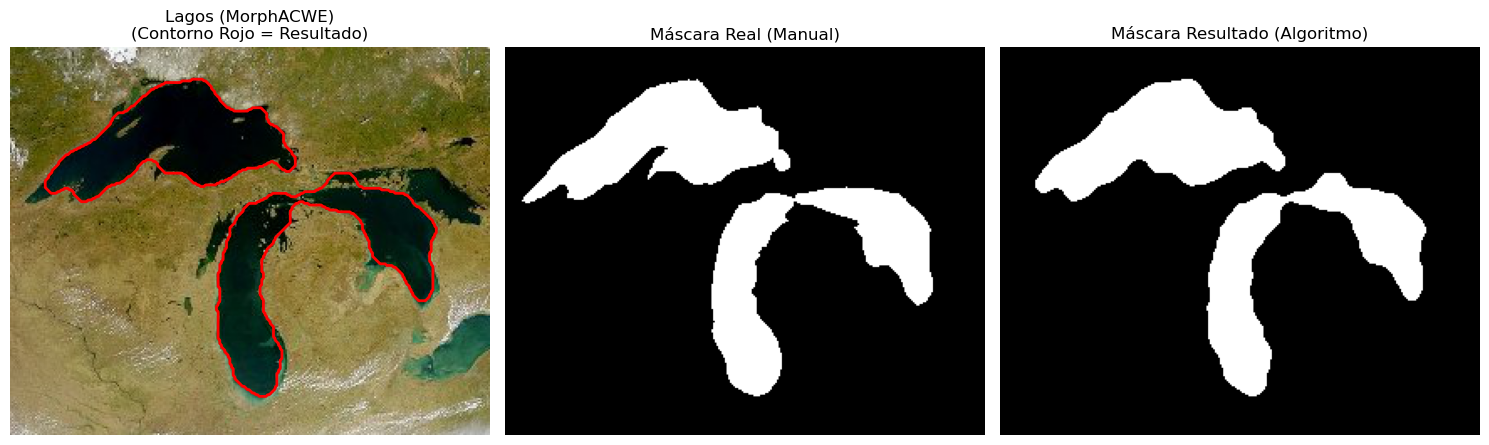


Procesando Estrella de Mar...
--- Estrella de Mar ---
Sensibilidad:  91.23%
Especificidad: 98.18%
Precisión:     96.54%
--------------------


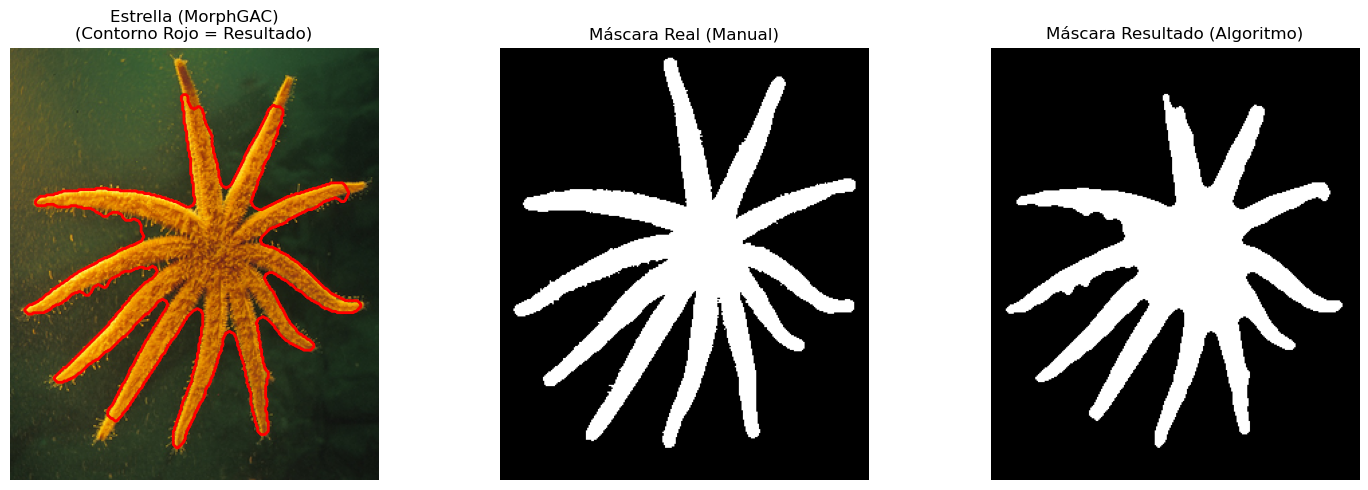


Procesando Nódulo...


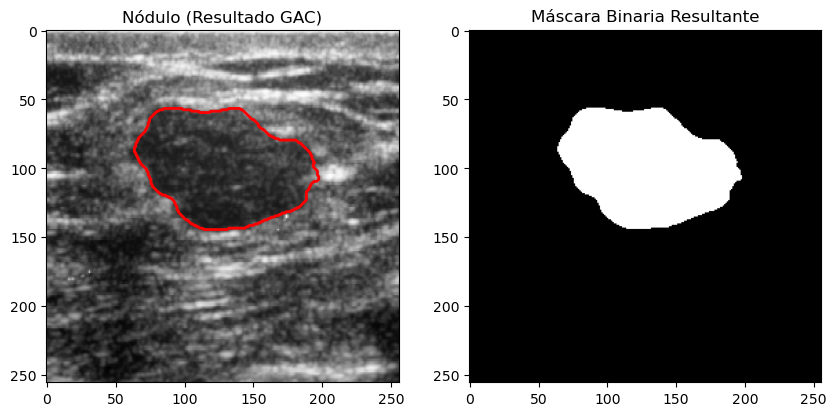

Nota: Métricas no calculadas para el nódulo por falta de archivo de máscara 'Ground Truth'.


In [35]:
# Función auxiliar para visualizar resultados
def visualizar_segmentacion(img_original, mask_gt, mask_resultado, titulo):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Imagen original con contorno resultante
    if len(img_original.shape) == 2:
        axes[0].imshow(img_original, cmap='gray')
    else:
        axes[0].imshow(img_original)
        
    axes[0].contour(mask_resultado, [0.5], colors='r', linewidths=2)
    axes[0].set_title(f'{titulo}\n(Contorno Rojo = Resultado)')
    axes[0].axis('off')
    
    # Máscara Ground Truth (Manual)
    axes[1].imshow(mask_gt, cmap='gray')
    axes[1].set_title('Máscara Real (Manual)')
    axes[1].axis('off')
    
    # Máscara Resultado (Algoritmo)
    axes[2].imshow(mask_resultado, cmap='gray')
    axes[2].set_title('Máscara Resultado (Algoritmo)')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------
# CASO 1: LAGO (Morphological Chan-Vese - ACWE)
# ---------------------------------------------------------
print("Procesando Lagos...")
# Cargar imagen y máscara
img_lakes = imread('images/lakes3.jpg') / 255.0
img_lakes_gray = rgb2gray(img_lakes)
mask_lakes_gt = imread('images/Mascara_lagos.png')
mask_lakes_gt = binarizar_mascara(mask_lakes_gt)

# Inicialización
init_ls_lakes = ms.circle_level_set(img_lakes_gray.shape, (80, 170), 25)

# Ejecutar MorphACWE
# Ajustar smoothing o lambda1/lambda2 si la sensibilidad es baja
mask_lakes_res = ms.morphological_chan_vese(img_lakes_gray, iterations=200,
                                           init_level_set=init_ls_lakes,
                                           smoothing=3, lambda1=1, lambda2=1)

# Evaluar y Mostrar
calcular_y_mostrar_metricas("Lagos", mask_lakes_gt, mask_lakes_res)
visualizar_segmentacion(img_lakes, mask_lakes_gt, mask_lakes_res, "Lagos (MorphACWE)")


# ---------------------------------------------------------
# CASO 2: ESTRELLA DE MAR (Morphological Geodesic Active Contours - GAC)
# ---------------------------------------------------------
print("\nProcesando Estrella de Mar...")
# Cargar
img_star = imread('images/seastar2.png') / 255.0
img_star_gray = rgb2gray(img_star)
mask_star_gt = imread('images/Mascara_estrella.png')
mask_star_gt = binarizar_mascara(mask_star_gt)

# Preprocesamiento g(I) para GAC (detectar bordes)
gimg_star = ms.inverse_gaussian_gradient(img_star_gray, alpha=1000, sigma=2)

# Inicialización
init_ls_star = ms.circle_level_set(img_star_gray.shape, (163, 137), 135)

# Ejecutar MorphGAC
# Balloon = 1 para expandir hacia afuera, -1 para contraer. Aquí expandimos o usamos bordes.
# threshold='auto' ayuda a detenerse en los bordes fuertes.
mask_star_res = ms.morphological_geodesic_active_contour(gimg_star, iterations=100,
                                             init_level_set=init_ls_star,
                                             smoothing=2, threshold=0.3,
                                             balloon=-1) # Usamos balloon negativo si la inicializacion cubre todo, o ver examples.py

# Evaluar y Mostrar
calcular_y_mostrar_metricas("Estrella de Mar", mask_star_gt, mask_star_res)
visualizar_segmentacion(img_star, mask_star_gt, mask_star_res, "Estrella (MorphGAC)")


# ---------------------------------------------------------
# CASO 3: NÓDULO (Ecografía) - MorphGAC
# ---------------------------------------------------------
print("\nProcesando Nódulo...")
# Nota: No has subido 'Mascara Nódulo.png', así que simularemos que no hay GT 
# o usaremos el resultado como demostración visual solamente si no existe la máscara real.
# Si tienes la máscara, cárgala igual que las anteriores.

img_nod = imread('images/mama07ORI.bmp')
if len(img_nod.shape) > 2: img_nod = img_nod[..., 0]
img_nod = img_nod / 255.0

# g(I)
gimg_nod = ms.inverse_gaussian_gradient(img_nod, alpha=1000, sigma=5.48)

# Inicialización
init_ls_nod = ms.circle_level_set(img_nod.shape, (100, 126), 20)

# Ejecutar
mask_nod_res = ms.morphological_geodesic_active_contour(gimg_nod, iterations=45,
                                             init_level_set=init_ls_nod,
                                             smoothing=1, threshold=0.31,
                                             balloon=1)

# Mostrar resultado (Sin métricas si no hay máscara manual)
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img_nod, cmap='gray')
ax[0].contour(mask_nod_res, [0.5], colors='r', linewidths=2)
ax[0].set_title('Nódulo (Resultado GAC)')
ax[1].imshow(mask_nod_res, cmap='gray')
ax[1].set_title('Máscara Binaria Resultante')
plt.show()
print("Nota: Métricas no calculadas para el nódulo por falta de archivo de máscara 'Ground Truth'.")

### Objetivo 1

Será doble:

1) Probar si os funciona la implementación de *active contours* que hay en la siguiente página web:

https://scikit-image.org/docs/stable/auto_examples/edges/plot_active_contours.html

2) Intentar poner en funcionamiento la imagen de ejemplo de ecografía, y la metodología de *Snakes* que hay en el siguiente repositorio:

https://github.com/pmneila/morphsnakes/tree/master

Lo primero que os aconsejo es mirar y entender el código **examples.py**, e intentarlo hacer funcionar, con la imagen **mama07ORI.bmp**.

Es posible que necesitéis guardar variables en ficheros porque el entorno no os permita visualizar la evolución de la *snake*. Pensad qué podéis hacer para poder ver el resultado que os dé el método, teniendo en cuenta el **README.me** del repositorio.

Como paso intermedio entre 1) y 2), podéis probar la imagen de ecografía, con la metodología de 1).

---

### Objetivo 2

Intentad hacer funcionar el método sobre las imágenes en color **lakes3.jpg** y **seastar2.png**. 

---

### Implementación de Métricas de Evaluación

A continuación, definimos las funciones para calcular la Sensibilidad, Especificidad y Precisión Global, tal como se solicita.

### Segmentación y Evaluación de Imágenes

Procesamos las imágenes solicitadas: Lagos, Estrella y Ecografía (Mama). Compararemos con las máscaras disponibles.

### Estudio de Variación de Parámetros (Alfa y Beta)

Investigamos el efecto de variar `alpha` (inverso de magnitud de gradiente) y `sigma` (suavizado gaussiano) en el método GAC para la imagen de Ecografía (o Lagos si se prefiere GAC). Asumimos que "alfa" y "beta" se refieren a estos parámetros de preprocesamiento.